In [44]:
import pandas as pd

# cargar aceleraciones
df_a = pd.read_csv("accel_ang2.csv")

# renombrar columnas
df_a = df_a.rename(columns={
    "inertial-6286.188861:estLinearAccelX": "ax",
    "inertial-6286.188861:estLinearAccelX:valid": "aXvalid",
    "inertial-6286.188861:estLinearAccelY": "ay",
    "inertial-6286.188861:estLinearAccelY:valid": "aYvalid",
    "inertial-6286.188861:estLinearAccelZ": "az",
    "inertial-6286.188861:estLinearAccelZ:valid": "aZvalid",
})

# quedarnos solo con datos válidos
df_a = df_a[
    (df_a["aXvalid"] == 1) &
    (df_a["aYvalid"] == 1) &
    (df_a["aZvalid"] == 1)
]

# df_a.drop(["aZvalid", "aYvalid", "aXvalid"], axis=1)

df_a["time_comp"] = df_a["Time"]*1e-8
df_a["time_comp"] = df_a["time_comp"].astype(int)
df_a["time_comp"] 

df_a["dt"] = df_a["Time"].diff() * 1e-9
# df_u

new_order = ['Time', 'ax', 'ay', 'az', 'dt']
df_a = df_a[new_order]

df_a

,Time,ax,ay,az,dt
0,1771622130451376384,0.003816,0.031436,0.061123,NaN
1,1771622130461423872,0.005611,0.017711,0.056661,0.010047
2,1771622130471371776,0.006301,0.036271,0.061147,0.009948
3,1771622130481222400,0.004411,0.005835,0.034826,0.009851
4,1771622130490975232,-0.007199,0.020422,0.042615,0.009753
...,...,...,...,...,...
2863,1771622159080844032,-0.004404,0.000184,0.032671,0.009791
2864,1771622159090539008,-0.005789,0.007724,0.045007,0.009695
2865,1771622159100142592,0.001703,0.001768,0.038660,0.009604
2866,1771622159109651456,-0.007563,0.005440,0.046788,0.009509


In [45]:
import numpy as np


# Inicializar columnas
for col in ["vx", "vy", "vz", "px", "py", "pz"]:
    df_a[col] = 0.0

p = np.zeros(3)
v = np.zeros(3)

# len(df_a)
for k in range(1, len(df_a)):

    dt = df_a.loc[k, "dt"]

    # Si el primer dt es NaN, lo saltamos
    if pd.isna(dt):
        continue

    a = df_a.loc[k, ["ax", "ay", "az"]].values

    # Velocidad
    v = v + a * dt

    # Posición
    p = p + v * dt

    # Guardar en el DataFrame
    df_a.loc[k, ["vx", "vy", "vz"]] = v
    df_a.loc[k, ["px", "py", "pz"]] = p
    
df_a

,Time,ax,ay,az,dt,vx,vy,vz,px,py,pz
0,1771622130451376384,0.003816,0.031436,0.061123,NaN,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000
1,1771622130461423872,0.005611,0.017711,0.056661,0.010047,0.000056,0.000178,0.000569,5.664810e-07,0.000002,0.000006
2,1771622130471371776,0.006301,0.036271,0.061147,0.009948,0.000119,0.000539,0.001178,1.750854e-06,0.000007,0.000017
3,1771622130481222400,0.004411,0.005835,0.034826,0.009851,0.000163,0.000596,0.001521,3.351648e-06,0.000013,0.000032
4,1771622130490975232,-0.007199,0.020422,0.042615,0.009753,0.000092,0.000795,0.001936,4.251768e-06,0.000021,0.000051
...,...,...,...,...,...,...,...,...,...,...,...
2863,1771622159080844032,-0.004404,0.000184,0.032671,0.009791,0.141787,0.104645,1.220248,3.947801e+00,3.034907,18.024576
2864,1771622159090539008,-0.005789,0.007724,0.045007,0.009695,0.141731,0.104720,1.220685,3.949175e+00,3.035922,18.036410
2865,1771622159100142592,0.001703,0.001768,0.038660,0.009604,0.141747,0.104737,1.221056,3.950536e+00,3.036928,18.048137
2866,1771622159109651456,-0.007563,0.005440,0.046788,0.009509,0.141675,0.104789,1.221501,3.951883e+00,3.037924,18.059752


In [46]:
import matplotlib.pyplot as plt

# Tiempo relativo en segundos
t = (df_a["Time"] - df_a["Time"].iloc[0]) * 1e-9

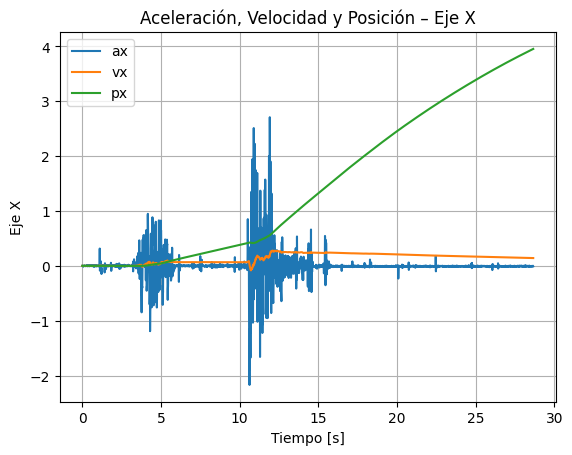

In [47]:
plt.figure()
plt.plot(t, df_a["ax"], label="ax")
plt.plot(t, df_a["vx"], label="vx")
plt.plot(t, df_a["px"], label="px")
plt.xlabel("Tiempo [s]")
plt.ylabel("Eje X")
plt.legend()
plt.grid(True)
plt.title("Aceleración, Velocidad y Posición – Eje X")
plt.show()


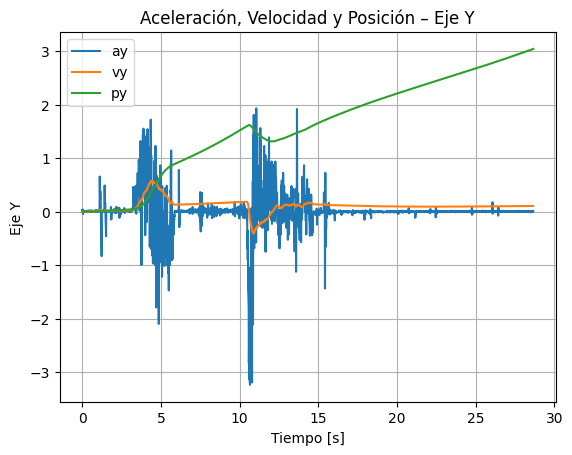

In [48]:
plt.figure()
plt.plot(t, df_a["ay"], label="ay")
plt.plot(t, df_a["vy"], label="vy")
plt.plot(t, df_a["py"], label="py")
plt.xlabel("Tiempo [s]")
plt.ylabel("Eje Y")
plt.legend()
plt.grid(True)
plt.title("Aceleración, Velocidad y Posición – Eje Y")
plt.show()


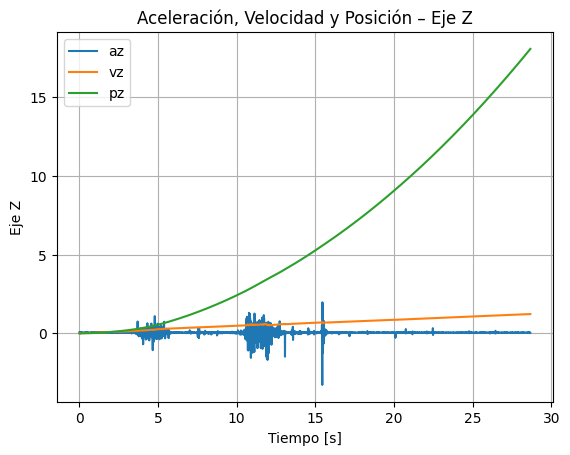

In [49]:
plt.figure()
plt.plot(t, df_a["az"], label="az")
plt.plot(t, df_a["vz"], label="vz")
plt.plot(t, df_a["pz"], label="pz")
plt.xlabel("Tiempo [s]")
plt.ylabel("Eje Z")
plt.legend()
plt.grid(True)
plt.title("Aceleración, Velocidad y Posición – Eje Z")
plt.show()


In [50]:
import pandas as pd


# --- cargar cuaterniones ---
df_q = pd.read_csv("cuaterniones_6.csv")

df_q = df_q.rename(columns={
    "inertial-6286.188861:estOrientQuaternion[0-0]": "q0",
    "inertial-6286.188861:estOrientQuaternion[0-1]": "q1",
    "inertial-6286.188861:estOrientQuaternion[0-2]": "q2",
    "inertial-6286.188861:estOrientQuaternion[0-3]": "q3",
    "inertial-6286.188861:estOrientQuaternion:valid": "qValid",
})

# Comprobar si es un valor válido
# df_q = df_q[df_q["inertial-6286.188861:estOrientQuaternion:valid"] == 1]

# df_q["dt"] = df_q["Time"].diff() * 1e-9
# print(df_q)

df_q["time_comp"] = df_q["Time"] * 1e-6
df_q["time_comp"] = df_q["time_comp"].astype(int)
# df_q["time_comp"]

# df_q["dt"] = df_q["Time"].diff() * 1e-9
# df_u

df_q

,Time,q0,q1,q2,q3,qValid,time_comp
0,1772488680841101568,1.000000,0.000830,0.000011,0.000231,1,1772488680841
1,1772488680850665216,1.000000,0.000830,0.000009,0.000231,1,1772488680850
2,1772488680860133376,1.000000,0.000830,0.000006,0.000232,1,1772488680860
3,1772488680869509632,1.000000,0.000831,0.000008,0.000233,1,1772488680869
4,1772488680878948096,1.000000,0.000828,0.000011,0.000231,1,1772488680878
...,...,...,...,...,...,...,...
6281,1772488743650959872,0.999447,0.001118,-0.000359,0.033233,1,1772488743650
6282,1772488743660678656,0.999447,0.001118,-0.000360,0.033239,1,1772488743660
6283,1772488743670300672,0.999447,0.001118,-0.000358,0.033242,1,1772488743670
6284,1772488743679828224,0.999447,0.001121,-0.000356,0.033246,1,1772488743679


In [51]:
# dt = df_q['dt'].dropna().values
# fs_est = 1 / np.mean(dt)

# print("fs estimada:", fs_est, "Hz")

In [52]:
# cargar aceleraciones
df_a = pd.read_csv("accel_ang_6.csv")

# renombrar columnas
df_a = df_a.rename(columns={
    "inertial-6286.188861:estAngularRateX": "arx",
    "inertial-6286.188861:estAngularRateX:valid": "arXvalid",
    "inertial-6286.188861:estAngularRateY": "ary",
    "inertial-6286.188861:estAngularRateY:valid": "arYvalid",
    "inertial-6286.188861:estAngularRateZ": "arz",
    "inertial-6286.188861:estAngularRateZ:valid": "alZvalid",
    "inertial-6286.188861:estLinearAccelX": "alx",
    "inertial-6286.188861:estLinearAccelX:valid": "alXvalid",
    "inertial-6286.188861:estLinearAccelY": "aly",
    "inertial-6286.188861:estLinearAccelY:valid": "alYvalid",
    "inertial-6286.188861:estLinearAccelZ": "alz",
    "inertial-6286.188861:estLinearAccelZ:valid": "alZvalid",
})

# quedarnos solo con datos válidos
# df_a = df_a[
#     (df_a["arXvalid"] == 1) &
#     (df_a["arYvalid"] == 1) &
#     (df_a["arZvalid"] == 1)
# ]

# df_a.drop(["aZvalid", "aYvalid", "aXvalid"], axis=1)

df_a["time_comp"] = df_a["Time"]*1e-6
df_a["time_comp"] = df_a["time_comp"].astype(int)
# df_a["time_comp"] 

# df_a["dt"] = df_a["Time"].diff() * 1e-9

df_a

,Time,alx,alXvalid,aly,alYvalid,alz,alZvalid,arx,arXvalid,ary,arYvalid,arz,alZvalid,time_comp
0,1772488680841101568,0.000825,1,0.000103,1,0.043242,1,-0.000087,1,0.000163,1,5.536785e-07,1,1772488680841
1,1772488680850665216,0.001237,1,-0.000300,1,0.043501,1,-0.000114,1,-0.000037,1,-3.029983e-05,1,1772488680850
2,1772488680860133376,-0.000130,1,-0.001537,1,0.040354,1,-0.000044,1,-0.000312,1,1.152584e-04,1,1772488680860
3,1772488680869509632,0.001215,1,-0.001273,1,0.042014,1,0.000029,1,0.000033,1,6.813303e-05,1,1772488680869
4,1772488680878948096,0.001534,1,-0.000973,1,0.047310,1,-0.000179,1,0.000307,1,-8.417429e-05,1,1772488680878
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6281,1772488743650959872,0.005722,1,-0.006814,1,0.045768,1,-0.000143,1,-0.000095,1,9.993338e-04,1,1772488743650
6282,1772488743660678656,0.004298,1,-0.006412,1,0.043839,1,0.000003,1,-0.000123,1,1.063040e-03,1,1772488743660
6283,1772488743670300672,0.003466,1,-0.005099,1,0.041308,1,0.000009,1,0.000022,1,8.227145e-04,1,1772488743670
6284,1772488743679828224,0.005140,1,-0.006743,1,0.040095,1,0.000168,1,0.000138,1,8.358741e-04,1,1772488743679


In [53]:
# dt = df_a['dt'].dropna().values
# fs_est = 1 / np.mean(dt)

# print("fs estimada:", fs_est, "Hz")

In [54]:
# import pandas as pd

# # Cargar datos
# data = pd.read_csv("imu_data.csv")

# # Eliminar primera fila (dt = NaN)
# data = data.dropna().reset_index(drop=True)

arx = df_a['arx'].values
ary = df_a['ary'].values
arz = df_a['arz'].values
alx = df_a['alx'].values
aly = df_a['aly'].values
alz = df_a['alz'].values

ang_acc = np.vstack((arx, ary, arz, alx, aly, alz)).T

ang_acc

array([[-8.70075601e-05,  1.62850338e-04,  5.53678547e-07,
         8.24904826e-04,  1.02732272e-04,  4.32415865e-02],
       [-1.14158815e-04, -3.73569856e-05, -3.02998305e-05,
         1.23659498e-03, -2.99503183e-04,  4.35005948e-02],
       [-4.37235503e-05, -3.11887852e-04,  1.15258415e-04,
        -1.29810374e-04, -1.53677526e-03,  4.03544530e-02],
       ...,
       [ 8.91234959e-06,  2.22054750e-05,  8.22714530e-04,
         3.46588786e-03, -5.09901438e-03,  4.13075350e-02],
       [ 1.67901075e-04,  1.37530325e-04,  8.35874118e-04,
         5.13966428e-03, -6.74321037e-03,  4.00950499e-02],
       [ 1.78797374e-04, -1.84719189e-04,  8.14523548e-04,
         5.44724613e-03, -6.45416463e-03,  4.13630269e-02]],
      shape=(6286, 6))

In [55]:
import numpy as np
from scipy.signal import butter, sosfilt

fs = 100.0      # Hz
fc = 10.0       # Hz
order = 4

Wn = fc / (fs / 2)

sos = butter(order, Wn, btype='low', output='sos')
print(sos)

accel_filt = sosfilt(sos, ang_acc, axis=0)
accel_filt

[[ 0.00482434  0.00964869  0.00482434  1.         -1.04859958  0.29614036]
 [ 1.          2.          1.          1.         -1.32091343  0.63273879]]


array([[-4.19754344e-07,  7.85645945e-07,  2.67113542e-09,
         3.97962412e-06,  4.95615756e-07,  2.08612261e-04],
       [-3.22437208e-06,  4.82395914e-06, -1.29162954e-07,
         3.13140264e-05,  1.71192481e-06,  1.53862031e-03],
       [-1.16013136e-05,  1.21007882e-05, -3.24868438e-07,
         1.12104719e-04, -7.31028277e-06,  5.44885902e-03],
       ...,
       [-7.32129798e-05,  1.80058499e-04,  1.00793261e-03,
         5.40488085e-03, -8.26296162e-03,  4.15743432e-02],
       [-5.70253666e-05,  1.20242687e-04,  1.06569942e-03,
         5.38719228e-03, -7.79476575e-03,  4.17979554e-02],
       [-3.69793443e-05,  5.16500789e-05,  1.07272792e-03,
         5.26872676e-03, -7.15711483e-03,  4.22543589e-02]],
      shape=(6286, 6))

In [56]:
from scipy.signal import butter, filtfilt

def butter_lowpass(fc, fs, order=4):
    wn = fc / (fs / 2)
    b, a = butter(order, wn, btype='low')
    return b, a

fc = 10  # Hz
b, a = butter_lowpass(fc, fs, order=4)

arx_f = filtfilt(b, a, arx)
ary_f = filtfilt(b, a, ary)
arz_f = filtfilt(b, a, arz)
alx_f = filtfilt(b, a, alx)
aly_f = filtfilt(b, a, aly)
alz_f = filtfilt(b, a, alz)
arx_f

array([-8.70994853e-05, -7.55880017e-05, -7.44075916e-05, ...,
        4.61032602e-05,  1.08176632e-04,  1.77255398e-04], shape=(6286,))

In [57]:
arx

array([-8.70075601e-05, -1.14158815e-04, -4.37235503e-05, ...,
        8.91234959e-06,  1.67901075e-04,  1.78797374e-04], shape=(6286,))

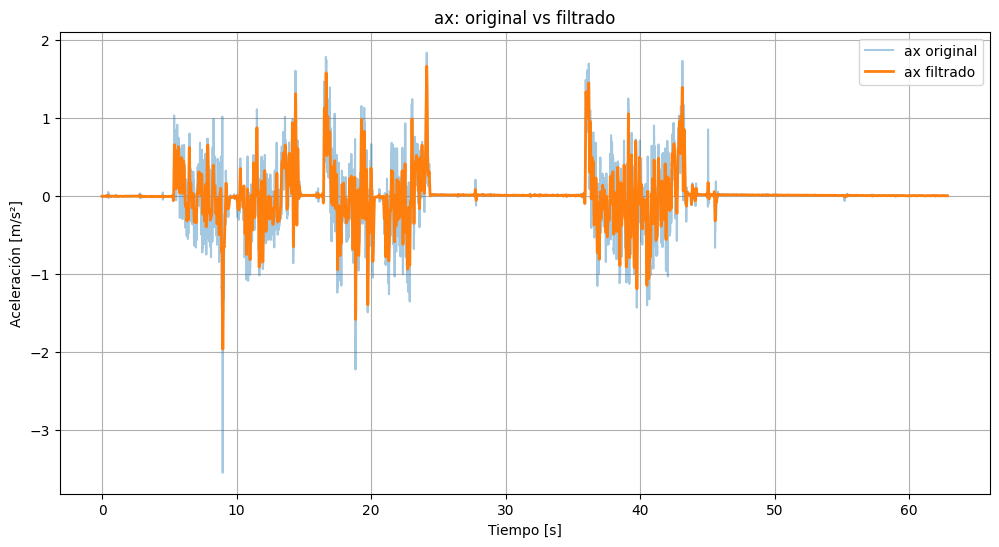

In [58]:
import matplotlib.pyplot as plt

# t = np.cumsum(dt)
N = len(alx)
t = np.arange(N) / fs

plt.figure(figsize=(12,6))
plt.plot(t, alx, label='ax original', alpha=0.4)
plt.plot(t, alx_f, label='ax filtrado', linewidth=2)
plt.xlabel("Tiempo [s]")
plt.ylabel("Aceleración [m/s²]")
plt.title("ax: original vs filtrado")
plt.legend()
plt.grid()
plt.show()

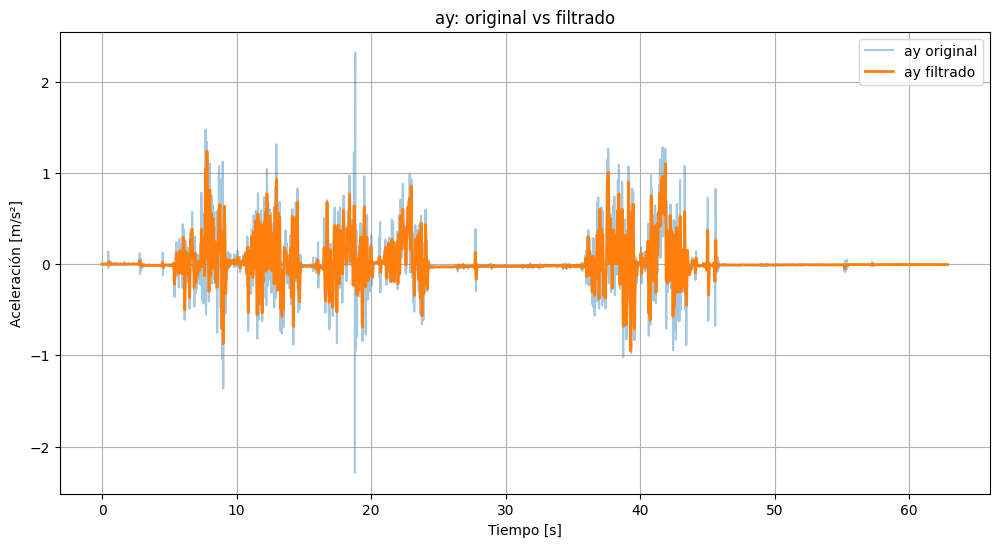

In [59]:
import matplotlib.pyplot as plt

# t = np.cumsum(dt)
N = len(aly)
t = np.arange(N) / fs

plt.figure(figsize=(12,6))
plt.plot(t, aly, label='ay original', alpha=0.4)
plt.plot(t, aly_f, label='ay filtrado', linewidth=2)
plt.xlabel("Tiempo [s]")
plt.ylabel("Aceleración [m/s²]")
plt.title("ay: original vs filtrado")
plt.legend()
plt.grid()
plt.show()

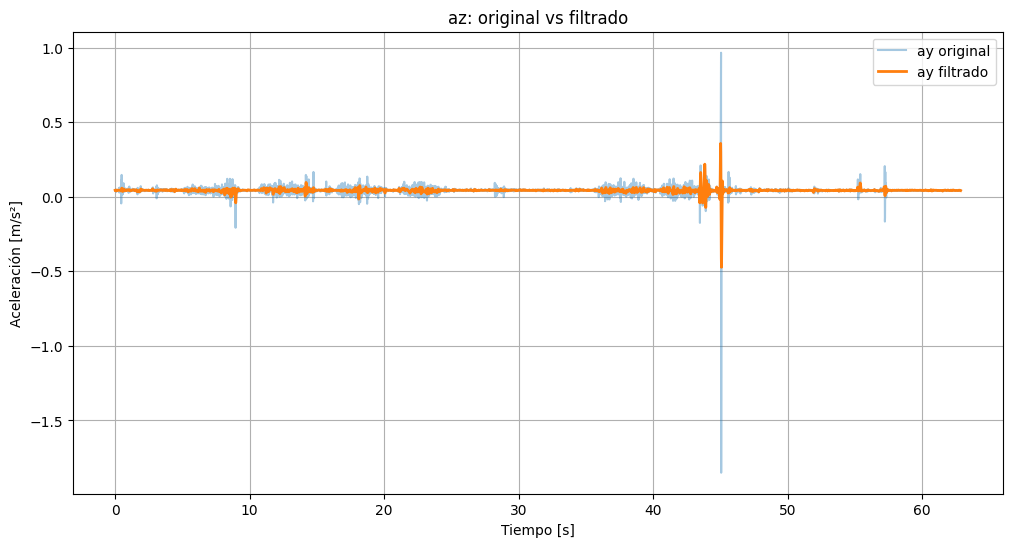

In [60]:
import matplotlib.pyplot as plt

# t = np.cumsum(dt)
N = len(alz)
t = np.arange(N) / fs

plt.figure(figsize=(12,6))
plt.plot(t, alz, label='ay original', alpha=0.4)
plt.plot(t, alz_f, label='ay filtrado', linewidth=2)
plt.xlabel("Tiempo [s]")
plt.ylabel("Aceleración [m/s²]")
plt.title("az: original vs filtrado")
plt.legend()
plt.grid()
plt.show()

In [61]:
print(alx_f.shape)
df_a['arx']

(6286,)


0      -0.000087
1      -0.000114
2      -0.000044
3       0.000029
4      -0.000179
          ...   
6281   -0.000143
6282    0.000003
6283    0.000009
6284    0.000168
6285    0.000179
Name: arx, Length: 6286, dtype: float64

In [62]:
# print(arx_f.shape)
# df_a['arx']
df_a['arx_f'] = arx_f
df_a['ary_f'] = ary_f
df_a['arz_f'] = arz_f
df_a['alx_f'] = alx_f
df_a['aly_f'] = aly_f
df_a['alz_f'] = alz_f
df_a

,Time,alx,alXvalid,aly,alYvalid,alz,alZvalid,arx,arXvalid,ary,arYvalid,arz,alZvalid,time_comp,arx_f,ary_f,arz_f,alx_f,aly_f,alz_f
0,1772488680841101568,0.000825,1,0.000103,1,0.043242,1,-0.000087,1,0.000163,1,5.536785e-07,1,1772488680841,-0.000087,0.000162,0.000001,0.000837,0.000107,0.043247
1,1772488680850665216,0.001237,1,-0.000300,1,0.043501,1,-0.000114,1,-0.000037,1,-3.029983e-05,1,1772488680850,-0.000076,0.000077,0.000018,0.001320,-0.000346,0.043984
2,1772488680860133376,-0.000130,1,-0.001537,1,0.040354,1,-0.000044,1,-0.000312,1,1.152584e-04,1,1772488680860,-0.000074,0.000011,0.000041,0.001746,-0.000714,0.044481
3,1772488680869509632,0.001215,1,-0.001273,1,0.042014,1,0.000029,1,0.000033,1,6.813303e-05,1,1772488680869,-0.000090,-0.000022,0.000072,0.002045,-0.000940,0.044528
4,1772488680878948096,0.001534,1,-0.000973,1,0.047310,1,-0.000179,1,0.000307,1,-8.417429e-05,1,1772488680878,-0.000123,-0.000017,0.000112,0.002123,-0.001020,0.043998
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6281,1772488743650959872,0.005722,1,-0.006814,1,0.045768,1,-0.000143,1,-0.000095,1,9.993338e-04,1,1772488743650,-0.000043,0.000055,0.001043,0.005041,-0.006866,0.042537
6282,1772488743660678656,0.004298,1,-0.006412,1,0.043839,1,0.000003,1,-0.000123,1,1.063040e-03,1,1772488743660,-0.000005,-0.000003,0.001010,0.004993,-0.006497,0.042580
6283,1772488743670300672,0.003466,1,-0.005099,1,0.041308,1,0.000009,1,0.000022,1,8.227145e-04,1,1772488743670,0.000046,-0.000063,0.000953,0.005051,-0.006316,0.042389
6284,1772488743679828224,0.005140,1,-0.006743,1,0.040095,1,0.000168,1,0.000138,1,8.358741e-04,1,1772488743679,0.000108,-0.000124,0.000884,0.005220,-0.006319,0.041967


In [63]:
df_q

,Time,q0,q1,q2,q3,qValid,time_comp
0,1772488680841101568,1.000000,0.000830,0.000011,0.000231,1,1772488680841
1,1772488680850665216,1.000000,0.000830,0.000009,0.000231,1,1772488680850
2,1772488680860133376,1.000000,0.000830,0.000006,0.000232,1,1772488680860
3,1772488680869509632,1.000000,0.000831,0.000008,0.000233,1,1772488680869
4,1772488680878948096,1.000000,0.000828,0.000011,0.000231,1,1772488680878
...,...,...,...,...,...,...,...
6281,1772488743650959872,0.999447,0.001118,-0.000359,0.033233,1,1772488743650
6282,1772488743660678656,0.999447,0.001118,-0.000360,0.033239,1,1772488743660
6283,1772488743670300672,0.999447,0.001118,-0.000358,0.033242,1,1772488743670
6284,1772488743679828224,0.999447,0.001121,-0.000356,0.033246,1,1772488743679


In [64]:
df_a

,Time,alx,alXvalid,aly,alYvalid,alz,alZvalid,arx,arXvalid,ary,arYvalid,arz,alZvalid,time_comp,arx_f,ary_f,arz_f,alx_f,aly_f,alz_f
0,1772488680841101568,0.000825,1,0.000103,1,0.043242,1,-0.000087,1,0.000163,1,5.536785e-07,1,1772488680841,-0.000087,0.000162,0.000001,0.000837,0.000107,0.043247
1,1772488680850665216,0.001237,1,-0.000300,1,0.043501,1,-0.000114,1,-0.000037,1,-3.029983e-05,1,1772488680850,-0.000076,0.000077,0.000018,0.001320,-0.000346,0.043984
2,1772488680860133376,-0.000130,1,-0.001537,1,0.040354,1,-0.000044,1,-0.000312,1,1.152584e-04,1,1772488680860,-0.000074,0.000011,0.000041,0.001746,-0.000714,0.044481
3,1772488680869509632,0.001215,1,-0.001273,1,0.042014,1,0.000029,1,0.000033,1,6.813303e-05,1,1772488680869,-0.000090,-0.000022,0.000072,0.002045,-0.000940,0.044528
4,1772488680878948096,0.001534,1,-0.000973,1,0.047310,1,-0.000179,1,0.000307,1,-8.417429e-05,1,1772488680878,-0.000123,-0.000017,0.000112,0.002123,-0.001020,0.043998
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6281,1772488743650959872,0.005722,1,-0.006814,1,0.045768,1,-0.000143,1,-0.000095,1,9.993338e-04,1,1772488743650,-0.000043,0.000055,0.001043,0.005041,-0.006866,0.042537
6282,1772488743660678656,0.004298,1,-0.006412,1,0.043839,1,0.000003,1,-0.000123,1,1.063040e-03,1,1772488743660,-0.000005,-0.000003,0.001010,0.004993,-0.006497,0.042580
6283,1772488743670300672,0.003466,1,-0.005099,1,0.041308,1,0.000009,1,0.000022,1,8.227145e-04,1,1772488743670,0.000046,-0.000063,0.000953,0.005051,-0.006316,0.042389
6284,1772488743679828224,0.005140,1,-0.006743,1,0.040095,1,0.000168,1,0.000138,1,8.358741e-04,1,1772488743679,0.000108,-0.000124,0.000884,0.005220,-0.006319,0.041967


In [65]:
df_u = pd.merge(
    df_q,
    df_a,
    on="time_comp",
    how="inner"
)
df_u

,Time_x,q0,q1,q2,q3,qValid,time_comp,Time_y,alx,alXvalid,...,ary,arYvalid,arz,alZvalid,arx_f,ary_f,arz_f,alx_f,aly_f,alz_f
0,1772488680841101568,1.000000,0.000830,0.000011,0.000231,1,1772488680841,1772488680841101568,0.000825,1,...,0.000163,1,5.536785e-07,1,-0.000087,0.000162,0.000001,0.000837,0.000107,0.043247
1,1772488680850665216,1.000000,0.000830,0.000009,0.000231,1,1772488680850,1772488680850665216,0.001237,1,...,-0.000037,1,-3.029983e-05,1,-0.000076,0.000077,0.000018,0.001320,-0.000346,0.043984
2,1772488680860133376,1.000000,0.000830,0.000006,0.000232,1,1772488680860,1772488680860133376,-0.000130,1,...,-0.000312,1,1.152584e-04,1,-0.000074,0.000011,0.000041,0.001746,-0.000714,0.044481
3,1772488680869509632,1.000000,0.000831,0.000008,0.000233,1,1772488680869,1772488680869509632,0.001215,1,...,0.000033,1,6.813303e-05,1,-0.000090,-0.000022,0.000072,0.002045,-0.000940,0.044528
4,1772488680878948096,1.000000,0.000828,0.000011,0.000231,1,1772488680878,1772488680878948096,0.001534,1,...,0.000307,1,-8.417429e-05,1,-0.000123,-0.000017,0.000112,0.002123,-0.001020,0.043998
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6281,1772488743650959872,0.999447,0.001118,-0.000359,0.033233,1,1772488743650,1772488743650959872,0.005722,1,...,-0.000095,1,9.993338e-04,1,-0.000043,0.000055,0.001043,0.005041,-0.006866,0.042537
6282,1772488743660678656,0.999447,0.001118,-0.000360,0.033239,1,1772488743660,1772488743660678656,0.004298,1,...,-0.000123,1,1.063040e-03,1,-0.000005,-0.000003,0.001010,0.004993,-0.006497,0.042580
6283,1772488743670300672,0.999447,0.001118,-0.000358,0.033242,1,1772488743670,1772488743670300672,0.003466,1,...,0.000022,1,8.227145e-04,1,0.000046,-0.000063,0.000953,0.005051,-0.006316,0.042389
6284,1772488743679828224,0.999447,0.001121,-0.000356,0.033246,1,1772488743679,1772488743679828224,0.005140,1,...,0.000138,1,8.358741e-04,1,0.000108,-0.000124,0.000884,0.005220,-0.006319,0.041967


In [66]:
df_u = df_u.rename(columns={"Time_x": "time"})
df_u.drop(["Time_y"], axis=1, inplace=True)
# df_u

df_u["dt"] = df_u["time"].diff() * 1e-9
# df_u

new_order = ['time', 'q0', 'q1', 'q2', 'q3', 'arx', 'ary', 'arz', 'alx', 'aly', 'alz','dt', 'arx_f', 'ary_f', 'arz_f', 'alx_f', 'aly_f', 'alz_f']
df_u = df_u[new_order]
# print(df_u)
df_u

,time,q0,q1,q2,q3,arx,ary,arz,alx,aly,alz,dt,arx_f,ary_f,arz_f,alx_f,aly_f,alz_f
0,1772488680841101568,1.000000,0.000830,0.000011,0.000231,-0.000087,0.000163,5.536785e-07,0.000825,0.000103,0.043242,NaN,-0.000087,0.000162,0.000001,0.000837,0.000107,0.043247
1,1772488680850665216,1.000000,0.000830,0.000009,0.000231,-0.000114,-0.000037,-3.029983e-05,0.001237,-0.000300,0.043501,0.009564,-0.000076,0.000077,0.000018,0.001320,-0.000346,0.043984
2,1772488680860133376,1.000000,0.000830,0.000006,0.000232,-0.000044,-0.000312,1.152584e-04,-0.000130,-0.001537,0.040354,0.009468,-0.000074,0.000011,0.000041,0.001746,-0.000714,0.044481
3,1772488680869509632,1.000000,0.000831,0.000008,0.000233,0.000029,0.000033,6.813303e-05,0.001215,-0.001273,0.042014,0.009376,-0.000090,-0.000022,0.000072,0.002045,-0.000940,0.044528
4,1772488680878948096,1.000000,0.000828,0.000011,0.000231,-0.000179,0.000307,-8.417429e-05,0.001534,-0.000973,0.047310,0.009438,-0.000123,-0.000017,0.000112,0.002123,-0.001020,0.043998
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6281,1772488743650959872,0.999447,0.001118,-0.000359,0.033233,-0.000143,-0.000095,9.993338e-04,0.005722,-0.006814,0.045768,0.009815,-0.000043,0.000055,0.001043,0.005041,-0.006866,0.042537
6282,1772488743660678656,0.999447,0.001118,-0.000360,0.033239,0.000003,-0.000123,1.063040e-03,0.004298,-0.006412,0.043839,0.009719,-0.000005,-0.000003,0.001010,0.004993,-0.006497,0.042580
6283,1772488743670300672,0.999447,0.001118,-0.000358,0.033242,0.000009,0.000022,8.227145e-04,0.003466,-0.005099,0.041308,0.009622,0.000046,-0.000063,0.000953,0.005051,-0.006316,0.042389
6284,1772488743679828224,0.999447,0.001121,-0.000356,0.033246,0.000168,0.000138,8.358741e-04,0.005140,-0.006743,0.040095,0.009528,0.000108,-0.000124,0.000884,0.005220,-0.006319,0.041967


In [67]:
# solo como comprobación

import numpy as np

dt = df_u['dt'].dropna().values
fs_est = 1 / np.mean(dt)

print("fs estimada:", fs_est, "Hz")

fs estimada: 100.00292646909237 Hz


In [68]:
import numpy as np

# Inicializar columnas
for col in ["vx", "vy", "vz", "px", "py", "pz"]:
    df_u[col] = 0.0

p = np.zeros(3)
v = np.ones(3)

# Umbrales
ACC_TH = 0.1       # m/s^2
GYRO_TH = np.deg2rad(1.0)  # rad/s

print(v.shape)
print(df_u.loc[k, ["vx", "vy", "vz"]].shape)
# len(df_a)

a = df_u.loc[2, ["alx", "aly", "alz"]].values
a.shape

v.shape
dt = 0.01
# np.zeros(3).shape

a = df_u.loc[2, ["alx", "aly", "alz"]].values.copy()
print(type(a), a.shape)
a[1] = 0.0
print(a[1], a.flags)

arr_1d = np.array([1, 2, 3, 4, 5])
print(arr_1d.shape)
arr_1d[2] = 99  # Modifies the third element (index 2)
print(arr_1d)


print(v, v.shape)
v[1] = 0
print(v, v.shape)

x = v + a#*dt
x

(3,)
(3,)
<class 'numpy.ndarray'> (3,)
0.0   C_CONTIGUOUS : True
  F_CONTIGUOUS : True
  OWNDATA : True
  WRITEABLE : True
  ALIGNED : True
  WRITEBACKIFCOPY : False

(5,)
[ 1  2 99  4  5]
[1. 1. 1.] (3,)
[1. 0. 1.] (3,)


array([0.99987019, 0.        , 1.04035445])

In [69]:
# a = df_a.loc[3, ["alx", "aly", "alz"]].values
# a

In [70]:
# def zupt_acc_ang(a, g, v):
#     if np.linalg.norm(a) < ACC_TH and np.linalg.norm(g) < GYRO_TH:
#         v = np.zeros(3)   # ZUPT duro

In [71]:
# ACC_TH_ENERGY = (0.02**2)*3 # = 0.0012

Threshold alx_f: 0.829385155298332
Threshold aly_f: 0.5984494746644323
Threshold alz_f: 0.09539360269820171
Threshold norm(alx_f,aly_f): 1.025116783684709
Threshold norm(alx_f,alz_f): 0.8461654687716529
Threshold norm(aly_f,alz_f): 0.592983898135615
Threshold norm(alx_f,aly_f,alz_f): 1.0150354582429522


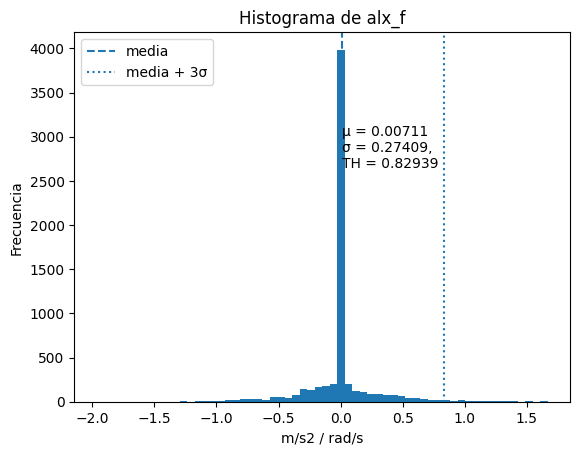

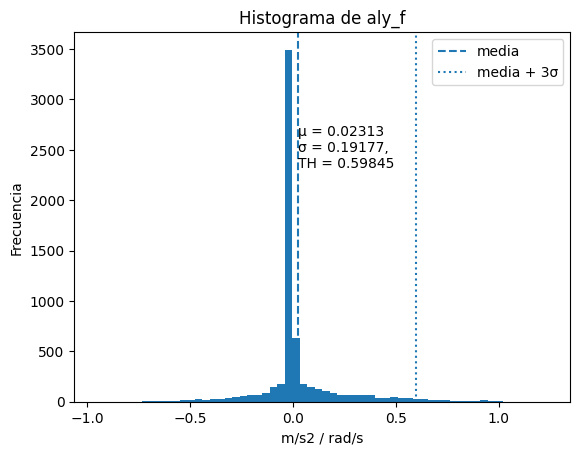

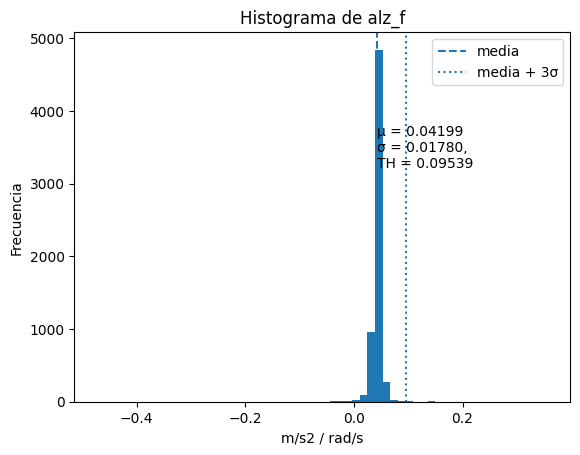

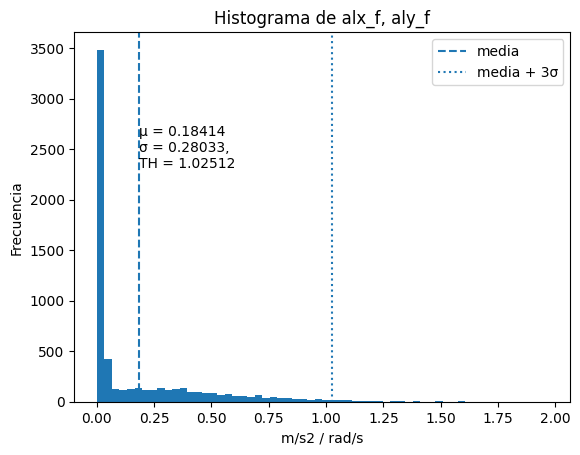

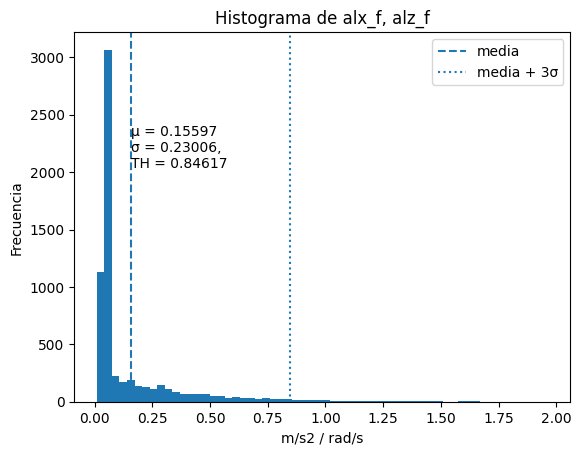

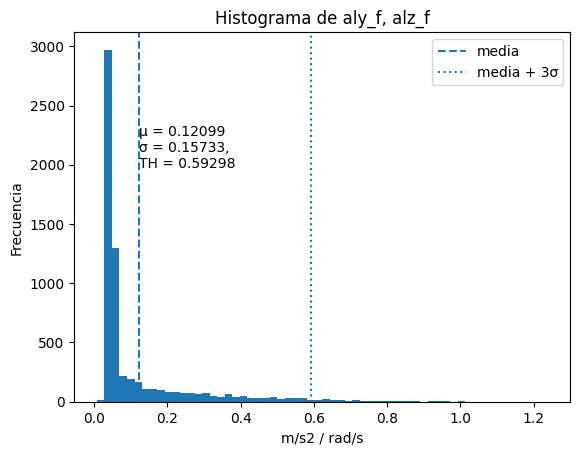

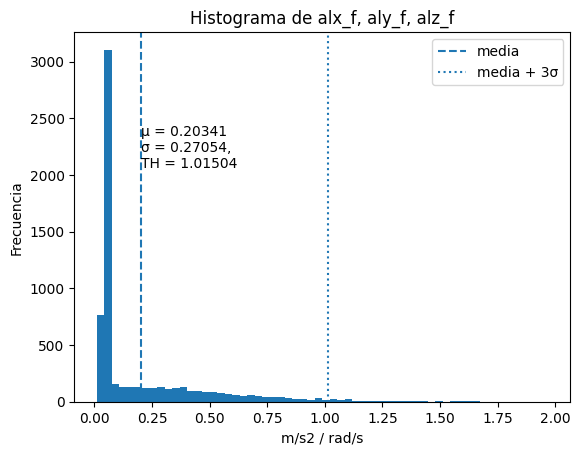

In [72]:
# σ describe ruido + vibración

# segun prueba obtener umbrales y ganancias
import numpy as np
import matplotlib.pyplot as plt

# accl = df_u[["alx_f", "aly_f", "alz_f"]].values#.copy()
# print(accl)
# gyro = df_u[["arx_f", "ary_f", "arz_f"]].values

def histogramaUnEje(axis):
    axis_values = df_u[axis].values
    # axis_values = np.linalg.norm(axis_values)

    axis_mean  = np.mean(axis_values)
    axis_std   = np.std(axis_values)
    th_value = axis_mean + 3*axis_std

    plt.figure()
    plt.hist(axis_values, bins=60)

    plt.axvline(axis_mean, linestyle='--', label='media')
    plt.axvline(axis_mean + 3*axis_std, linestyle=':', label='media + 3σ')

    # Texto dentro de la gráfica
    plt.text(
        axis_mean,
        plt.ylim()[1]*0.75,
        f"μ = {axis_mean:.5f}\nσ = {axis_std:.5f},\nTH = {th_value:.5f}",
        verticalalignment='top'
    )

    plt.xlabel("m/s2 / rad/s")
    plt.ylabel("Frecuencia")
    plt.title(f"Histograma de {axis}")
    plt.legend()

    print(f"Threshold {axis}: {th_value}")

def histogramaDosEjes(axis1, axis2):
    axis_values = df_u[[axis1, axis2]].values
    axis_norm  = np.linalg.norm(axis_values, axis=1)

    axis_mean  = np.mean(axis_norm)
    axis_std   = np.std(axis_norm)
    th_value = axis_mean + 3*axis_std

    plt.figure()
    plt.hist(axis_norm, bins=60)

    plt.axvline(axis_mean, linestyle='--', label='media')
    plt.axvline(axis_mean + 3*axis_std, linestyle=':', label='media + 3σ')

    # Texto dentro de la gráfica
    plt.text(
        axis_mean,
        plt.ylim()[1]*0.75,
        f"μ = {axis_mean:.5f}\nσ = {axis_std:.5f},\nTH = {th_value:.5f}",
        verticalalignment='top'
    )

    plt.xlabel("m/s2 / rad/s")
    plt.ylabel("Frecuencia")
    plt.title(f"Histograma de {axis1}, {axis2}")
    plt.legend()

    print(f"Threshold norm({axis1},{axis2}): {th_value}")

def histogramaTresEjes(axis1, axis2, axis3):
    axis_values = df_u[[axis1, axis2, axis3]].values
    axis_norm  = np.linalg.norm(axis_values, axis=1)

    axis_mean  = np.mean(axis_norm)
    axis_std   = np.std(axis_norm)
    th_value = axis_mean + 3*axis_std

    plt.figure()
    plt.hist(axis_norm, bins=60)

    plt.axvline(axis_mean, linestyle='--', label='media')
    plt.axvline(axis_mean + 3*axis_std, linestyle=':', label='media + 3σ')

    # Texto dentro de la gráfica
    plt.text(
        axis_mean,
        plt.ylim()[1]*0.75,
        f"μ = {axis_mean:.5f}\nσ = {axis_std:.5f},\nTH = {th_value:.5f}",
        verticalalignment='top'
    )

    plt.xlabel("m/s2 / rad/s")
    plt.ylabel("Frecuencia")
    plt.title(f"Histograma de {axis1}, {axis2}, {axis3}")
    plt.legend()
    
    print(f"Threshold norm({axis1},{axis2},{axis3}): {th_value}")

histogramaUnEje("alx_f")
histogramaUnEje("aly_f")
histogramaUnEje("alz_f")
histogramaDosEjes("alx_f", "aly_f")
histogramaDosEjes("alx_f", "alz_f")
histogramaDosEjes("aly_f", "alz_f")
histogramaTresEjes("alx_f", "aly_f", "alz_f")

Threshold arx_f: 0.06796786485116968
Threshold ary_f: 0.013415372037277318
Threshold arz_f: 1.0900265012191266
Threshold norm(arx_f,ary_f): 0.07295367810722148
Threshold norm(arx_f,arz_f): 1.1396524677231339
Threshold norm(ary_f,arz_f): 1.1382833682008133
Threshold norm(arx_f,ary_f,arz_f): 1.1396781021149576


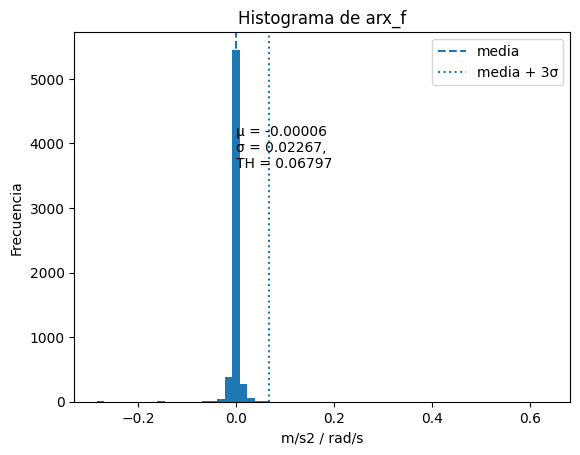

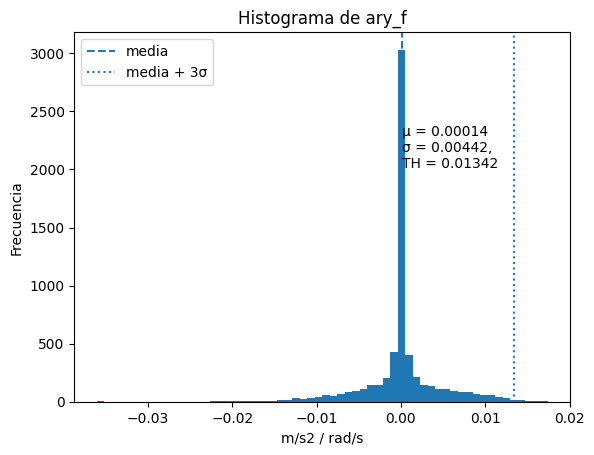

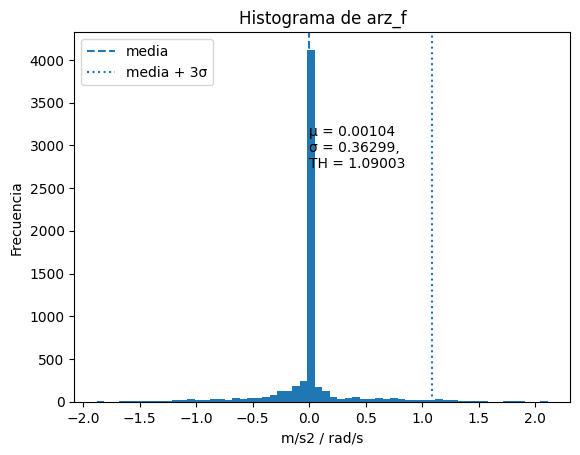

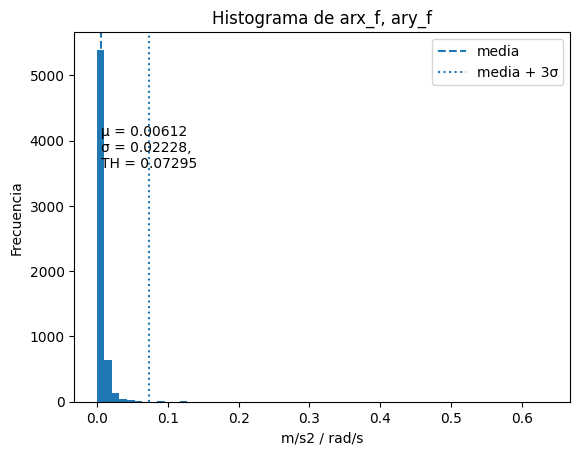

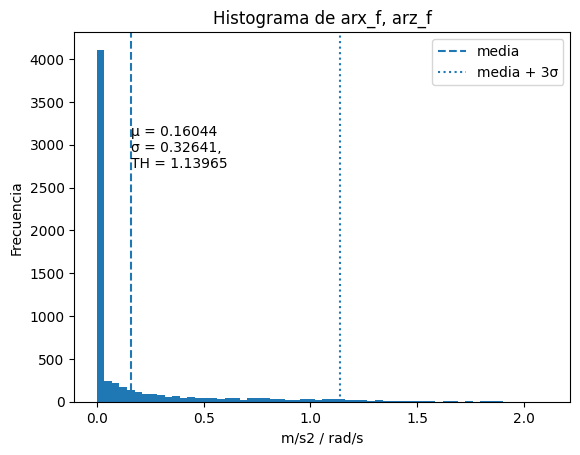

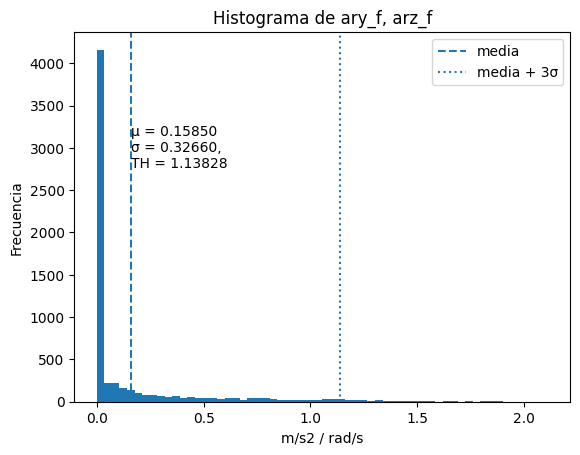

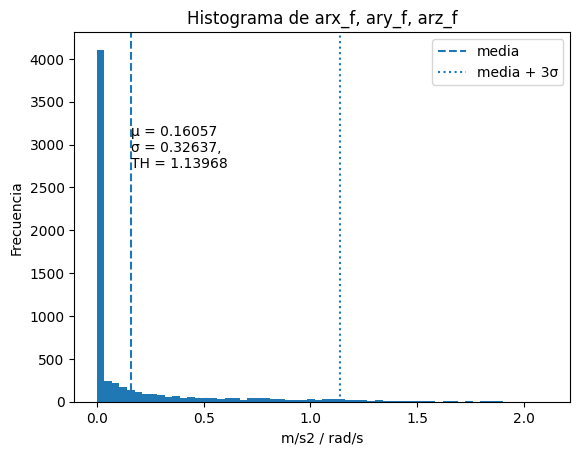

In [73]:
histogramaUnEje("arx_f")
histogramaUnEje("ary_f")
histogramaUnEje("arz_f")
histogramaDosEjes("arx_f", "ary_f")
histogramaDosEjes("arx_f", "arz_f")
histogramaDosEjes("ary_f", "arz_f")
histogramaTresEjes("arx_f", "ary_f", "arz_f")

In [74]:
"""ACC_TH   = 0.15          # m/s²
GYRO_TH  = np.deg2rad(1)

K_zupt   = 0.5
K_nhc_y  = 0.8
K_nhc_z  = 0.9

G_acc    = 0.8
G_gyro   = 1.0"""

'ACC_TH   = 0.15          # m/s²\nGYRO_TH  = np.deg2rad(1)\n\nK_zupt   = 0.5\nK_nhc_y  = 0.8\nK_nhc_z  = 0.9\n\nG_acc    = 0.8\nG_gyro   = 1.0'

In [75]:
x1 = 2.5
x0 = 0.5
x = 1 / (1+((np.e)**-(1*(x-x))))
x

array([0.5, 0.5, 0.5])

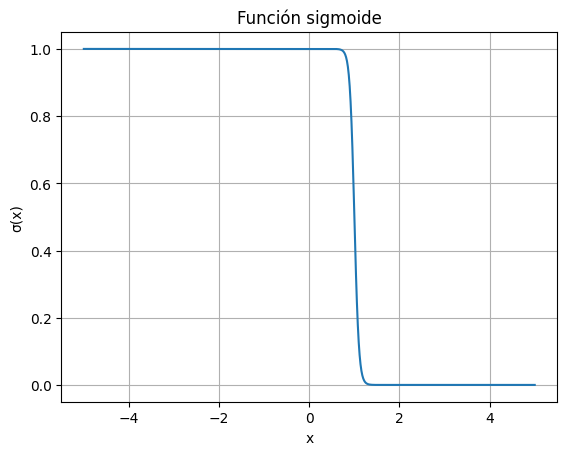

In [76]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid_k(x, ZUPT_X0=1.0, ZUPT_SIGMOID_GAIN=20.0):
    # k = 10 # que tan rápido crece la transición, espacio entre rangos
    # x0 = 0.5 # punto de activación - umbral # control de reposo
    valor_min = 0
    valor_max = 1
    # s = 1 / (1 + np.exp(-k*(x-x0)))
    # z = 1 / (1 + np.exp(k * (x - x0)))
    # z = np.clip(z, 0, 60)  # evita overflow

    z = ZUPT_SIGMOID_GAIN * (x - ZUPT_X0)
    z = np.clip(z, -10, 10)  # evita overflow
    z = 1 / (1 + np.exp(z))
    return valor_min + (valor_max - valor_min) * z

x = np.linspace(-5, 5, 1000)
y = sigmoid_k(x)

plt.figure()
plt.plot(x, y)
plt.xlabel("x")
plt.ylabel("σ(x)")
plt.title("Función sigmoide")
plt.grid(True)
plt.show()

# Criterio de eleccion de ruido
# ACC_TH  ≈ 3σ_acc
# GYRO_TH ≈ 3σ_gyro

In [77]:
pruebinia = sigmoid_k(0.527151, ZUPT_X0=1.0, ZUPT_SIGMOID_GAIN=10.0)
pruebinia

np.float64(0.9912376484362222)

In [78]:
y = 1 / (1+((np.e)**-2.5))
y

0.9241418199787566

In [79]:
# G_acc ≈ 1.0 en recta

# G_acc ≈ 0.7 si vibra mucho

# G_acc ≈ 0.3 si hay mucho ruido

In [ ]:
from scipy.spatial.transform import Rotation as R

def sigmoid_k(x, ZUPT_X0=1.0, ZUPT_SIGMOID_GAIN=20.0):
    valor_min = 0
    valor_max = 1
    z = ZUPT_SIGMOID_GAIN * (x - ZUPT_X0)
    z = np.clip(z, -10, 10)
    z = 1 / (1 + np.exp(z))
    return valor_min + (valor_max - valor_min) * z

    """ 
    G_acc = 0.8   # 1 = full confianza
    G_gyro = 1.0

    # Umbrales de ZUPT
    ACC_TH = 0.269
    GYRO_TH = 0.0172

    K_zupt = 0.5

    # # restricciones vehículo
    K_nhc_y = 0.2   # lateral
    K_nhc_z = 0.1   # vertical
    """

def ins(df=df_u,
        G_acc=0.8,
        G_gyro=1.0,
        ACC_TH=0.269,
        GYRO_TH=0.0172,
        ZUPT_GAIN=0.5,
        ZUPT_X0=1.0,
        ZUPT_SIGMOID_GAIN=1.0,
        K_nhc_y=0.2,
        K_nhc_z=0.1,
        dt = 0.01):

    p = np.zeros(3)
    v = np.zeros(3)
    v_body = np.zeros(3)

    for k in range(0, len(df)):

        if pd.isna(dt):
            continue

        a_body = df.loc[k, ["alx_f", "aly_f", "alz_f"]].values.copy()
        g = df.loc[k, ["arx_f", "ary_f", "arz_f"]].values

        gyro_gain = np.linalg.norm(G_gyro * g)

        q = df.loc[k, ["q0", "q1", "q2", "q3"]].values
        # 1) Normalizar cuaternión
        q = q / np.linalg.norm(q)

        # 2) Rotación body → inercial
        r = R.from_quat([q[1], q[2], q[3], q[0]])
        R_nb = r.as_matrix().T   # body → nav

        # 3) Aceleración en marco inercial
        a_nav = G_acc * (R_nb @ a_body)

        df.loc[k, ["a_nav_x", "a_nav_y", "a_nav_z"]] = a_nav

        # Velocidad
        v = v + a_nav * dt

        df.loc[k, ["v_int_x", "v_int_y", "v_int_z"]] = v

        acc_norm  = np.linalg.norm(a_body)
        gyro_norm = np.linalg.norm(gyro_gain)

        s_acc  = acc_norm  / ACC_TH
        s_gyro = gyro_norm / GYRO_TH

        zupt_score = max(s_acc, s_gyro)

        df.loc[k, ["acc_norm", "gyro_norm", "s_acc", "s_gyro", "zupt_score"]] = acc_norm, gyro_norm, s_acc, s_gyro, zupt_score

        # w_zupt = smooth_step(zupt_score)
        w_zupt = sigmoid_k(zupt_score, ZUPT_X0, ZUPT_SIGMOID_GAIN)
        # w_zupt = sigmoid_k(zupt_score, x0=1.0, k=1.0)

        v -= ZUPT_GAIN * w_zupt * v

        # velocidad en body frame
        v_body = R_nb.T @ v

        v_body[1] = K_nhc_y * v_body[1]   # no deslizamiento lateral
        v_body[2] = K_nhc_z * v_body[2]   # no salto vertical (opcional)

        df.loc[k, ["v_nhc_x", "v_nhc_y", "v_nhc_z"]] = v_body

        # volver a nav
        v = R_nb @ v_body

        # Posición
        p = p + v * dt

        df.loc[k, ["vx", "vy", "vz"]] = v
        df.loc[k, ["px", "py", "pz"]] = p
        
    # print(df)
    # df_u

In [ ]:
# ins()

KeyboardInterrupt: 

In [ ]:
# from scipy.spatial.transform import Rotation as R

# p = np.zeros(3)
# v = np.zeros(3)
# v_body = np.zeros(3)

# # def smooth_step(x, x0=1.0, k=10.0):
# #     return 1.0 / (1.0 + np.exp(k*(x - x0)))

# for k in range(0, len(df_u)):

#     # dt = df_a.loc[k, "dt"]
#     dt = 0.01

#     # Si el primer dt es NaN, lo saltamos
#     if pd.isna(dt):
#         continue

#     a_body = df_u.loc[k, ["alx_f", "aly_f", "alz_f"]].values.copy()

#     G_acc = 0.8   # 1 = full confianza

#     g = df_u.loc[k, ["arx_f", "ary_f", "arz_f"]].values

#     G_gyro = 1.0
#     # a_body[1:] = 0

#     gyro_gain = np.linalg.norm(G_gyro * g)

#     q = df_u.loc[k, ["q0", "q1", "q2", "q3"]].values

#     # 1) Normalizar cuaternión (seguridad numérica)
#     q = q / np.linalg.norm(q)

#     # 2) Rotación body → inercial (pasiva)
#     r = R.from_quat([q[1], q[2], q[3], q[0]])
#     R_nb = r.as_matrix().T   # body → nav

#     # 3) Aceleración en marco inercial
#     a_nav = G_acc * (R_nb @ a_body)

#     df_u.loc[k, ["a_nav_x", "a_nav_y", "a_nav_z"]] = a_nav

#     # Velocidad
#     v = v + a_nav * dt

#     df_u.loc[k, ["v_int_x", "v_int_y", "v_int_z"]] = v

#     # Detección ZUPT
#     # vk+1 ​= vk ​− Kzupt​ * vk​
#     # Caso A
#     # if np.linalg.norm(acc[k]) < ACC_TH and np.linalg.norm(gyro[k]) < GYRO_TH:

#     # Umbrales // se obtienen de prueba en estático // evaluar si se obtiene en calibracion
#     ACC_TH = 0.269       # m/s^2
#     # GYRO_TH = np.deg2rad(0.7)  # 0.012 rad/s
#     GYRO_TH = 0.0172  # rad/s / obtenido de estaod en reposo


#     acc_norm  = np.linalg.norm(a_body)
#     gyro_norm = np.linalg.norm(gyro_gain)

#     s_acc  = acc_norm  / ACC_TH
#     s_gyro = gyro_norm / GYRO_TH

#     zupt_score = max(s_acc, s_gyro)
#     # zupt_score = max(acc_norm, gyro_norm)

#     df_u.loc[k, ["acc_norm", "gyro_norm", "s_acc", "s_gyro", "zupt_score"]] = acc_norm, gyro_norm, s_acc, s_gyro, zupt_score
#     # if acc_norm < ACC_TH and gyro_norm < GYRO_TH:
#     #     # v = np.zeros(3)   # ZUPT duro
#     #     v_body[:] = 0.0

#     K_zupt = 0.5   # ganancia ZUPT (tunable)

#     # w_zupt = smooth_step(zupt_score)
#     w_zupt = sigmoid_k(zupt_score, x0=1.0, k=1.0)

#     v -= K_zupt * w_zupt * v
    
#     # df_u.loc[k, ["v_zupt_x", "v_zupt_y", "v_zupt_z"]] = v_zupt

#     # velocidad en body frame
#     v_body = R_nb.T @ v

#     # else:
#     # NHC suave

#     # K_nhc_y = 0.8   # lateral
#     # K_nhc_z = 0.9   # vertical

#     K_nhc_y = 0.2   # lateral
#     K_nhc_z = 0.1   # vertical

#     # velocidad en body frame
#     v_body = R_nb.T @ v

#     # # restricciones vehículo
#     # v_body[1] -= K_nhc_y * v_body[1]   # no deslizamiento lateral
#     # v_body[2] -= K_nhc_z * v_body[2]   # no salto vertical (opcional)
#     # # v_body[1:] = 0.0

#     v_body[1] = K_nhc_y * v_body[1]   # no deslizamiento lateral
#     v_body[2] = K_nhc_z * v_body[2]   # no salto vertical (opcional)

#     # volver a nav
#     v = R_nb @ v_body

#     # Posición
#     p = p + v * dt

#     # print(df_a.loc[k, ["vx", "vy", "vz"]].shape)


#     # zupt = (np.linalg.norm(a_body) < ACC_TH and np.linalg.norm(g) < GYRO_TH)

#     # if zupt:
#     #     # eje principal de movimiento
#     #     v[1] = 0.0   # Y duro

#     #     # ejes no excitados → corrección más agresiva
#     #     if abs(v[0]) < 0.02:
#     #         v[0] = 0.0
#     #     if abs(v[2]) < 0.02:
#     #         v[2] = 0.0

#     # E = np.mean(np.sum(a_window**2, axis=1))
#     # if E < ACC_TH_ENERGY:
#     #     v = np.zeros(3)

#     # Guardar en el DataFrame
#     # print(df_a.loc[k, ["vx", "vy", "vz"]].shape)
#     df_u.loc[k, ["vx", "vy", "vz"]] = v
#     df_u.loc[k, ["px", "py", "pz"]] = p
    
# # print(df_u)
# df_u

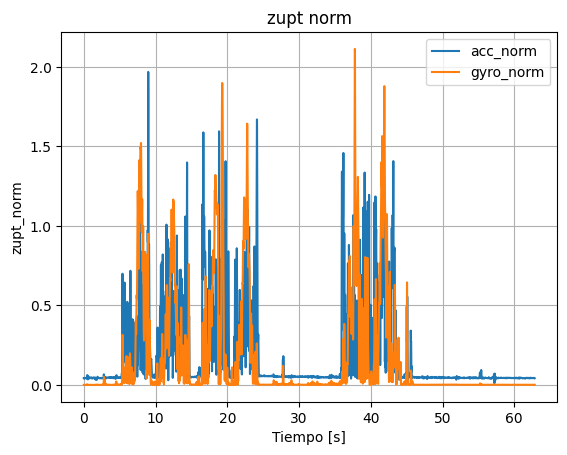

In [ ]:
plt.figure()
plt.plot(t, df_u["acc_norm"], label="acc_norm")
plt.plot(t, df_u["gyro_norm"], label="gyro_norm")
# plt.plot(t, alx, label='ax original', alpha=0.4)
# plt.plot(t, df_u["zupt_score"], label="zupt_score", alpha=0.4)
plt.xlabel("Tiempo [s]")
plt.ylabel("zupt_norm")
plt.legend()
plt.grid(True)
plt.title("zupt norm")
plt.show()

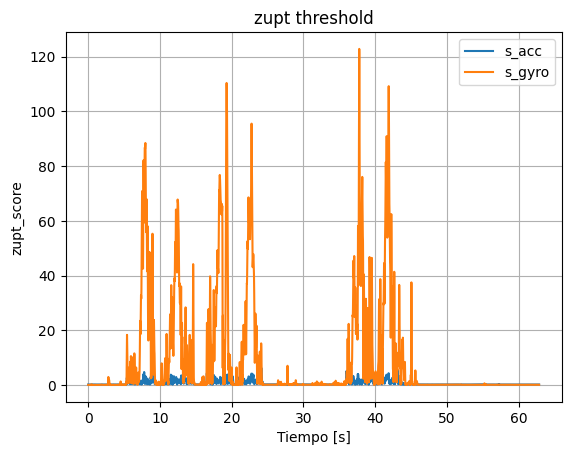

In [ ]:
plt.figure()
plt.plot(t, df_u["s_acc"], label="s_acc")
plt.plot(t, df_u["s_gyro"], label="s_gyro")
# plt.plot(t, alx, label='ax original', alpha=0.4)
# plt.plot(t, df_u["zupt_score"], label="zupt_score", alpha=0.4)
plt.xlabel("Tiempo [s]")
plt.ylabel("zupt_score")
plt.legend()
plt.grid(True)
plt.title("zupt threshold")
plt.show()

In [ ]:
"""# 1. ZUPT DURO
if ||a|| < ACC_TH and ||ω|| < GYRO_TH:
    v = 0

# 2. ZUPT como realimentación
vk+1​ = vk ​− Kzupt​ vk​

# 3. Detector zupT continuo (sin umbral duro)
# 3.1 Metrica de reposo (score)
acc_norm  = np.linalg.norm(a_body)
gyro_norm = np.linalg.norm(g)

s_acc  = acc_norm  / ACC_TH
s_gyro = gyro_norm / GYRO_TH

zupt_score = max(s_acc, s_gyro)

# 3.2 Activacion suave (funcion logistica)
def smooth_step(x, x0=1.0, k=10.0):
    return 1.0 / (1.0 + np.exp(k*(x - x0)))

w_zupt = smooth_step(zupt_score) 
# w_zupt = 1 -> ZUPT fuerte
# w_zupt = 0 -> sin ZUPT

# 4 ZUPT suave con ganancia
K_zupt = 0.5 # ganancia ZUPT (tuneable)

v -= K_zupt * w_zupt * v

# 5 HNC suave (no holonómica bien hecha)
# 5.1 Pasar velocidad a body
v_body = R_nb.T @ v"""

'# 1. ZUPT DURO\nif ||a|| < ACC_TH and ||ω|| < GYRO_TH:\n    v = 0\n\n# 2. ZUPT como realimentación\nvk+1\u200b = vk \u200b− Kzupt\u200b vk\u200b\n\n# 3. Detector zupT continuo (sin umbral duro)\n# 3.1 Metrica de reposo (score)\nacc_norm  = np.linalg.norm(a_body)\ngyro_norm = np.linalg.norm(g)\n\ns_acc  = acc_norm  / ACC_TH\ns_gyro = gyro_norm / GYRO_TH\n\nzupt_score = max(s_acc, s_gyro)\n\n# 3.2 Activacion suave (funcion logistica)\ndef smooth_step(x, x0=1.0, k=10.0):\n    return 1.0 / (1.0 + np.exp(k*(x - x0)))\n\nw_zupt = smooth_step(zupt_score) \n# w_zupt = 1 -> ZUPT fuerte\n# w_zupt = 0 -> sin ZUPT\n\n# 4 ZUPT suave con ganancia\nK_zupt = 0.5 # ganancia ZUPT (tuneable)\n\nv -= K_zupt * w_zupt * v\n\n# 5 HNC suave (no holonómica bien hecha)\n# 5.1 Pasar velocidad a body\nv_body = R_nb.T @ v'

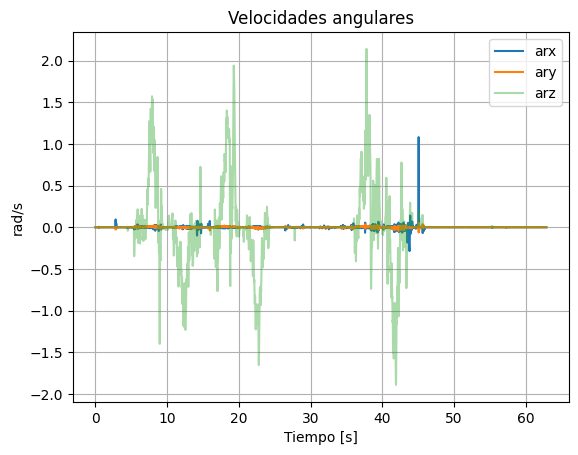

array([-8.70994853e-05, -7.55880017e-05, -7.44075916e-05, ...,
        4.61032602e-05,  1.08176632e-04,  1.77255398e-04], shape=(6286,))

In [ ]:
plt.figure()
plt.plot(t, df_u["arx"], label="arx")
plt.plot(t, df_u["ary"], label="ary")
# plt.plot(t, alx, label='ax original', alpha=0.4)
plt.plot(t, df_u["arz"], label="arz", alpha=0.4)
plt.xlabel("Tiempo [s]")
plt.ylabel("rad/s")
plt.legend()
plt.grid(True)
plt.title("Velocidades angulares")
plt.show()

arx_f	

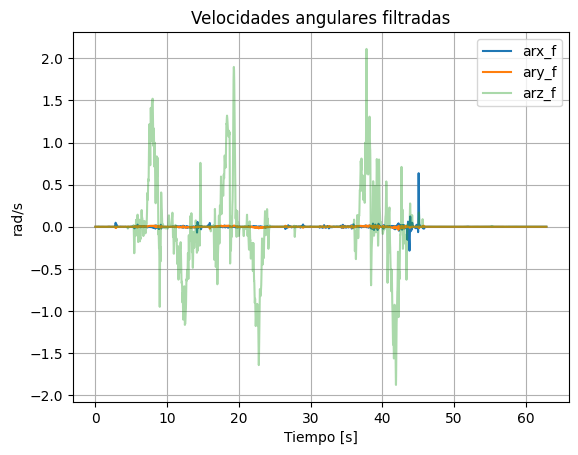

In [ ]:
plt.figure()
plt.plot(t, df_u["arx_f"], label="arx_f")
plt.plot(t, df_u["ary_f"], label="ary_f")
# plt.plot(t, alx, label='ax original', alpha=0.4)
plt.plot(t, df_u["arz_f"], label="arz_f", alpha=0.4)
plt.xlabel("Tiempo [s]")
plt.ylabel("rad/s")
plt.legend()
plt.grid(True)
plt.title("Velocidades angulares filtradas")
plt.show()

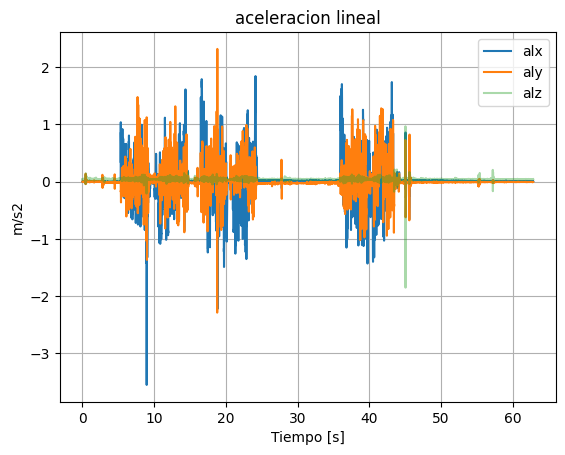

In [ ]:
plt.figure()
plt.plot(t, df_u["alx"], label="alx")
plt.plot(t, df_u["aly"], label="aly")
# plt.plot(t, alx, label='ax original', alpha=0.4)
plt.plot(t, df_u["alz"], label="alz", alpha=0.4)
plt.xlabel("Tiempo [s]")
plt.ylabel("m/s2")
plt.legend()
plt.grid(True)
plt.title("aceleracion lineal")
plt.show()

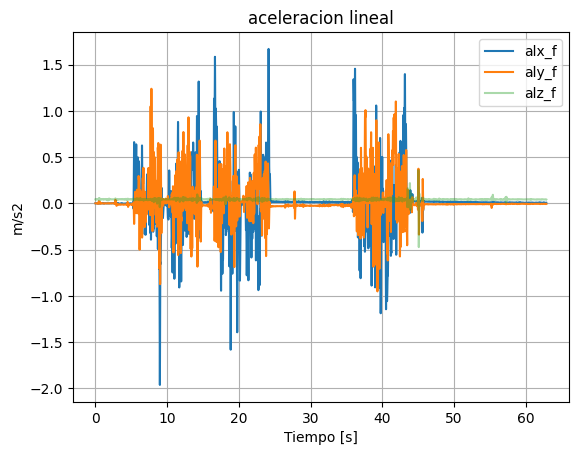

In [ ]:
plt.figure()
plt.plot(t, df_u["alx_f"], label="alx_f")
plt.plot(t, df_u["aly_f"], label="aly_f")
# plt.plot(t, alx, label='ax original', alpha=0.4)
plt.plot(t, df_u["alz_f"], label="alz_f", alpha=0.4)
plt.xlabel("Tiempo [s]")
plt.ylabel("m/s2")
plt.legend()
plt.grid(True)
plt.title("aceleracion lineal")
plt.show()

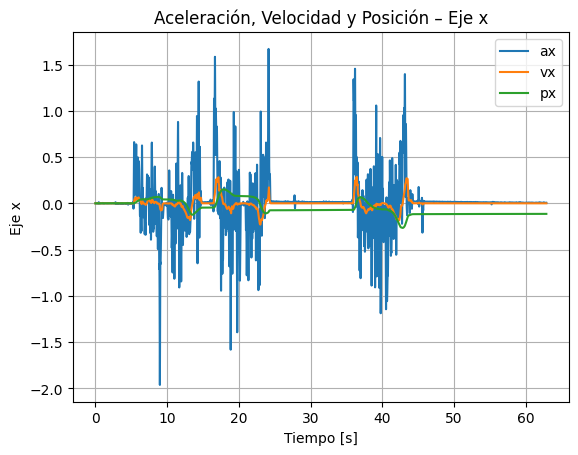

In [ ]:
def plot_unEje_ac_v_p(axi):
    plt.figure()
    plt.plot(t, df_u[f"al{axi}_f"], label=f"a{axi}")
    plt.plot(t, df_u[f"v{axi}"], label=f"v{axi}")
    plt.plot(t, df_u[f"p{axi}"], label=f"p{axi}")
    plt.xlabel("Tiempo [s]")
    plt.ylabel(f"Eje {axi}")
    plt.legend()
    plt.grid(True)
    plt.title(f"Aceleración, Velocidad y Posición – Eje {axi}")
    plt.show()

plot_unEje_ac_v_p("x")

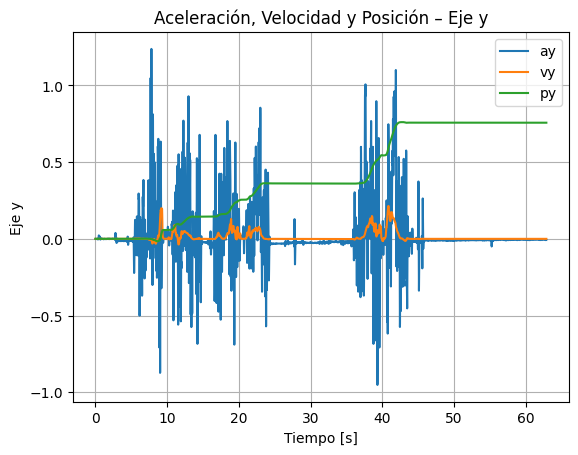

In [ ]:
# import matplotlib as plt
# # def plot_unEje_ac_v_p():
# plt.figure()
# plt.plot(t, df_u["aly_f"], label="ay")
# plt.plot(t, df_u["vy"], label="vy")
# plt.plot(t, df_u["py"], label="py")
# plt.xlabel("Tiempo [s]")
# plt.ylabel("Eje Y")
# plt.legend()
# plt.grid(True)
# plt.title("Aceleración, Velocidad y Posición – Eje Y")
# plt.show()
# # plot_unEje_ac_v_p()

plot_unEje_ac_v_p("y")

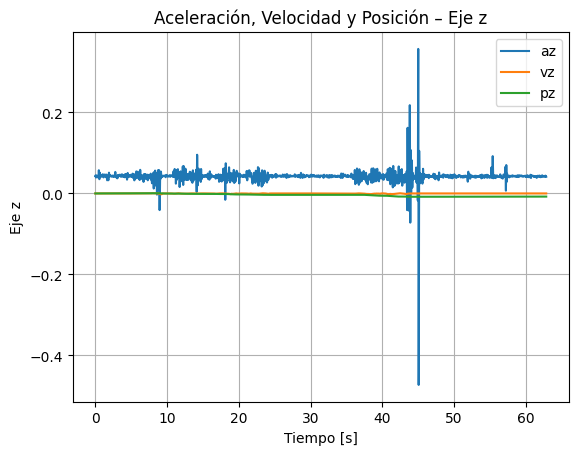

In [ ]:
# plt.figure()
# plt.plot(t, df_u["alz_f"], label="az")
# plt.plot(t, df_u["vz"], label="vz")
# plt.plot(t, df_u["pz"], label="pz")
# plt.xlabel("Tiempo [s]")
# plt.ylabel("Eje Z")
# plt.legend()
# plt.grid(True)
# plt.title("Aceleración, Velocidad y Posición – Eje Z")
# plt.show()

plot_unEje_ac_v_p("z")

In [ ]:
a = df_u.loc[5, ["alx", "aly", "alz"]].values
norm = np.linalg.norm(a)
a_norm = a / np.linalg.norm(a)
print(a)
print(norm)
print(a_norm)
print(a[0], abs(a[0]))

[ 0.00323096 -0.00103919  0.04799348]
0.04811333781991012
[ 0.06715318 -0.02159878  0.99750887]
0.00323096383363 0.00323096383363


In [82]:
def plot_unEje(df, axi, params, save_path):

    plt.figure()
    plt.plot(t, df[f"al{axi}_f"], label=f"a{axi}")
    plt.plot(t, df[f"v{axi}"], label=f"v{axi}")
    plt.plot(t, df[f"p{axi}"], label=f"p{axi}")

    plt.xlabel("Tiempo [s]")
    plt.ylabel(f"Eje {axi}")
    plt.legend()
    plt.grid(True)

    title = (
        f"ACC_TH={params['ACC_TH']} | "
        f"GYRO_TH={params['GYRO_TH']} | "
        f"ZUPT_GAIN={params['ZUPT_GAIN']} | "
        f"SIG={params['SIG_GAIN']}"
    )

    plt.title(title)
    plt.savefig(save_path)
    plt.close()

In [90]:
def plot_xyz(df, params, save_path):

    fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

    ejes = ["x", "y", "z"]

    for i, axi in enumerate(ejes):

        axes[i].plot(t, df[f"al{axi}_f"], label=f"a{axi}")
        axes[i].plot(t, df[f"v{axi}"], label=f"v{axi}")
        axes[i].plot(t, df[f"p{axi}"], label=f"p{axi}")

        axes[i].set_ylabel(f"Eje {axi}")
        axes[i].grid(True)
        axes[i].legend()

    axes[2].set_xlabel("Tiempo [s]")

    title = (
        f"ACC_TH={params['ACC_TH']} | "
        f"GYRO_TH={params['GYRO_TH']} | "
        f"ZUPT_GAIN={params['ZUPT_GAIN']} | "
        f"SIG={params['SIG_GAIN']}"
    )

    fig.suptitle(title, fontsize=12)
    plt.tight_layout(rect=[0, 0, 1, 0.97])

    plt.savefig(save_path)
    plt.close()

In [ ]:
import os
import itertools

os.makedirs("resultados2", exist_ok=True)

ACC_TH_vals = [0.118, 0.225, 0.269]
GYRO_TH_vals = [0.012, 0.015, 0.0172]
ZUPT_GAIN_vals = [0.3, 0.4, 0.5]
SIGMOID_GAIN_vals = [1, 2, 3, 4, 5]

for ACC_TH, GYRO_TH, ZUPT_GAIN, SIG_GAIN in itertools.product(
        ACC_TH_vals,
        GYRO_TH_vals,
        ZUPT_GAIN_vals,
        SIGMOID_GAIN_vals):

    df_test = df_u.copy()

    ins(
        df_test,
        ACC_TH=ACC_TH,
        GYRO_TH=GYRO_TH,
        ZUPT_GAIN=ZUPT_GAIN,
        ZUPT_SIGMOID_GAIN=SIG_GAIN
    )

    params = {
        "ACC_TH": ACC_TH,
        "GYRO_TH": GYRO_TH,
        "ZUPT_GAIN": ZUPT_GAIN,
        "SIG_GAIN": SIG_GAIN
    }

    filename = f"resultados/A{ACC_TH}_G{GYRO_TH}_Z{ZUPT_GAIN}_S{SIG_GAIN}.png"
    
    plot_xyz(df_test, params, filename)

                     time        q0        q1        q2        q3       arx  \
0     1772488680841101568  1.000000  0.000830  0.000011  0.000231 -0.000087   
1     1772488680850665216  1.000000  0.000830  0.000009  0.000231 -0.000114   
2     1772488680860133376  1.000000  0.000830  0.000006  0.000232 -0.000044   
3     1772488680869509632  1.000000  0.000831  0.000008  0.000233  0.000029   
4     1772488680878948096  1.000000  0.000828  0.000011  0.000231 -0.000179   
...                   ...       ...       ...       ...       ...       ...   
6281  1772488743650959872  0.999447  0.001118 -0.000359  0.033233 -0.000143   
6282  1772488743660678656  0.999447  0.001118 -0.000360  0.033239  0.000003   
6283  1772488743670300672  0.999447  0.001118 -0.000358  0.033242  0.000009   
6284  1772488743679828224  0.999447  0.001121 -0.000356  0.033246  0.000168   
6285  1772488743689262336  0.999446  0.001122 -0.000359  0.033250  0.000179   

           ary           arz       alx       aly  .

In [ ]:
# # ZUPT parcial

# EPS_ACCEL = 0.1      # m/s^2
# VAR_ACCEL = 0.02     # (m/s^2)^2
# MIN_SAMPLES = int(1.0 * fs)

# zupt = np.zeros(len(accel_filt), dtype=bool)
# counter = 0

# for k in range(N, len(accel_filt)):
#     acc_win = accel_filt[k-N:k]
    
#     acc_var = np.mean(np.var(acc_win, axis=0))
#     acc_dev = abs(acc_norm[k] - g)

#     stationary = (
#         acc_dev < EPS_ACCEL and
#         acc_var < VAR_ACCEL
#     )

#     if stationary:
#         counter += 1
#         if counter >= MIN_SAMPLES:
#             zupt[k] = True
#     else:
#         counter = 0

In [ ]:
# # magnitud total del ZUPT

# acc_mag = np.sqrt(ax**2 + ay**2 + az**2)
# acc_mag_f = np.sqrt(ax_f**2 + ay_f**2 + az_f**2)

# plt.figure(figsize=(12,6))
# plt.plot(t, acc_mag, label='|a| original', alpha=0.4)
# plt.plot(t, acc_mag_f, label='|a| filtrado', linewidth=2)
# plt.axhline(9.81, color='k', linestyle='--', label='g')
# plt.legend()
# plt.grid()
# plt.title("Magnitud de aceleración")
# plt.show()

In [ ]:
# Diseño de umbrales para ZUPT (criterio práctico)

# ZUPT no se diseña “a ojo”, se basa en:

# Aceleración cerca de g

# Baja varianza

# Giroscopio bajo (si lo tienes)

# Umbrales típicos (100 Hz)
# Variable	Umbral típico
# |a| − g	< 0.05 – 0.15 m/s²
# σ(a) ventana	< 0.02 – 0.05 m/s²
# |ω|	< 0.5 – 2 deg/s
# Ventana	0.2 – 0.5 s

In [ ]:
# Eso es ingeniería bien hecha:

# FFT → identificar banda útil

# Allan → ruido y bias

# Datos reales → ajustar fc y umbrales

In [ ]:
# from scipy.signal import sosfilt

# # gyro_filt = sosfilt(sos, gyro_raw)
# accel_filt = sosfilt(sos, accel_raw)

In [ ]:
# from scipy.signal import sosfiltfilt

# gyro_filt = sosfiltfilt(sos, gyro_raw)